In [1]:
# ===================== 1. 导入必需库 =====================
import anndata as ad

# ===================== 2. 读取你的 h5ad 文件 =====================
# 你的文件完整路径（直接用，无需修改）
file_path = "/home/zhangjunyi/xiangmu/nichecompass-main/datasets/Human_breast_cancer/Human_breast_cancer_ViHBC/Human_breast_cancer_integrated.h5ad"

print("正在读取 h5ad 文件...")
adata = ad.read_h5ad(file_path)
print("文件读取成功！")
print("="*60)

# ===================== 3. 查看 基因名（核心！） =====================
print("【前 20 个基因名】：")
gene_names = adata.var.index.tolist()
print(gene_names[:20])
print("="*60)

# ===================== 4. 自动判断基因名格式 =====================
first_gene = gene_names[0]

if first_gene.startswith("ENSG"):
    print("❌ 检测结果：Ensembl ID 格式（例如 ENSG00000141510）")
    print("⚠️  警告：SpaCET 无法直接使用，需要转换为 Gene Symbol！")
else:
    print("✅ 检测结果：标准 Gene Symbol 格式（例如 TP53/ACTB）")
    print("🎉 完美！可以直接运行 SpaCET 代码，无需任何修改！")

正在读取 h5ad 文件...
文件读取成功！
【前 20 个基因名】：
['MIR1302-2HG', 'FAM138A', 'OR4F5', 'AL627309.1', 'AL627309.3', 'AL627309.2', 'AL627309.5', 'AL627309.4', 'AP006222.2', 'AL732372.1', 'OR4F29', 'AC114498.1', 'OR4F16', 'AL669831.2', 'LINC01409', 'FAM87B', 'LINC01128', 'LINC00115', 'FAM41C', 'AL645608.6']
✅ 检测结果：标准 Gene Symbol 格式（例如 TP53/ACTB）
🎉 完美！可以直接运行 SpaCET 代码，无需任何修改！


将SpaCET的细胞类型比例放入到h5ad文件中

In [4]:
import anndata as ad
import pandas as pd

# ==========================================
# 1. 设置文件路径
# ==========================================
# 你的原始 h5ad 文件路径
path_h5ad_original = "/home/zhangjunyi/xiangmu/nichecompass-main/datasets/Human_breast_cancer/Human_breast_cancer_ViHBC/Human_breast_cancer_integrated.h5ad"

# 你的 SpaCET 结果 CSV 文件路径
path_spacet_csv = "/home/zhangjunyi/xiangmu/nichecompass-main/datasets/Human_breast_cancer/Human_breast_cancer_ViHBC/SpaCET_CellFractions_Result.csv"

# 输出文件路径（建议不要覆盖原文件，生成一个新的）
path_h5ad_output = "/home/zhangjunyi/xiangmu/nichecompass-main/datasets/Human_breast_cancer/Human_breast_cancer_ViHBC/Human_breast_cancer_integrated_with_SpaCET.h5ad"

# ==========================================
# 2. 读取数据
# ==========================================
print("正在读取数据...")

# 读取原始 h5ad
adata = ad.read_h5ad(path_h5ad_original)

# 读取 SpaCET CSV
# 假设 CSV 的第一列是 Spot ID，我们将其设为 index
spacet_df = pd.read_csv(path_spacet_csv, index_col=0)

print(f"✅ 原始 h5ad 包含 {adata.n_obs} 个 Spots")
print(f"✅ SpaCET 结果包含 {spacet_df.shape[0]} 个 Spots")

# ==========================================
# 3. 【关键】检查并对齐 Spot ID
# ==========================================
# 这一步极其重要，防止因为 ID 不匹配导致数据错位
# 找出共同的 Spot ID
common_spots = adata.obs_names.intersection(spacet_df.index)

if len(common_spots) == 0:
    raise ValueError("❌ 错误：原始 h5ad 和 SpaCET 结果没有匹配的 Spot ID！请检查 CSV 的第一列是否为正确的 Spot 名称。")
elif len(common_spots) < adata.n_obs:
    print(f"⚠️  警告：有 {adata.n_obs - len(common_spots)} 个 Spots 在 SpaCET 结果中未找到（可能是在 SpaCET QC 步骤被过滤了）。")
    # 只保留共同的 Spots（可选，或者你选择保留所有，缺失值填 NA）
    # 这里我们选择只保留共同的，以保证数据完整性
    adata = adata[common_spots].copy()

# 重新排序 SpaCET 的 DataFrame，使其顺序与 h5ad 完全一致
spacet_df_aligned = spacet_df.reindex(adata.obs_names)

# ==========================================
# 4. 合并注入到 h5ad
# ==========================================
print("正在合并数据...")

# 将 SpaCET 的所有列合并到 adata.obs 中
# 为了防止列名冲突，可以给 SpaCET 的列加上前缀（可选，这里直接合并）
# spacet_df_aligned = spacet_df_aligned.add_prefix('SpaCET_') 

adata.obs = adata.obs.join(spacet_df_aligned)

print("✅ 合并完成！adata.obs 中新增了以下列：")
print(spacet_df_aligned.columns.tolist())

# ==========================================
# 5. 保存新的 h5ad 文件
# ==========================================
print(f"正在保存新文件至：{path_h5ad_output}")
adata.write_h5ad(path_h5ad_output)

print("🎉 全部完成！你现在可以在 Python 中加载新的 h5ad 文件进行后续分析了。")

正在读取数据...
✅ 原始 h5ad 包含 3798 个 Spots
✅ SpaCET 结果包含 3798 个 Spots
正在合并数据...
✅ 合并完成！adata.obs 中新增了以下列：
['Malignant', 'CAF', 'Endothelial', 'Plasma', 'B cell', 'T CD4', 'T CD8', 'NK', 'cDC', 'pDC', 'Macrophage', 'Mast', 'Neutrophil', 'Unidentifiable', 'B cell naive', 'B cell non-switched memory', 'B cell switched memory', 'B cell exhausted', 'T CD4 naive', 'Th1', 'Th2', 'Th17', 'Tfh', 'Treg', 'T CD8 naive', 'T CD8 central memory', 'T CD8 effector memory', 'T CD8 effector', 'T CD8 exhausted', 'cDC1 CLEC9A', 'cDC2 CD1C', 'cDC3 LAMP3', 'Macrophage M1', 'Macrophage M2', 'Macrophage other']
正在保存新文件至：/home/zhangjunyi/xiangmu/nichecompass-main/datasets/Human_breast_cancer/Human_breast_cancer_ViHBC/Human_breast_cancer_integrated_with_SpaCET.h5ad
🎉 全部完成！你现在可以在 Python 中加载新的 h5ad 文件进行后续分析了。


使用GMM计算阈值
高斯混合模型 (Gaussian Mixture Model, GMM)：假设数据由“低分（非肿瘤）”和“高分（肿瘤）”两个正态分布混合而成，寻找两个分布概率相交的点作为阈值。（最推荐，能处理方差不同的分布）

正在加载数据...
正在使用高斯混合模型 (GMM) 拟合数据分布...
✨ [无监督] 自动计算出的最优划分阈值为: 0.5282


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f


✅ 图片已保存至: /home/zhangjunyi/xiangmu/nichecompass-main/outputs/Human_breast_cancer_ViHBC/zhibiao/SpaCET/GMM_Malignant_Threshold_Plot.png


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

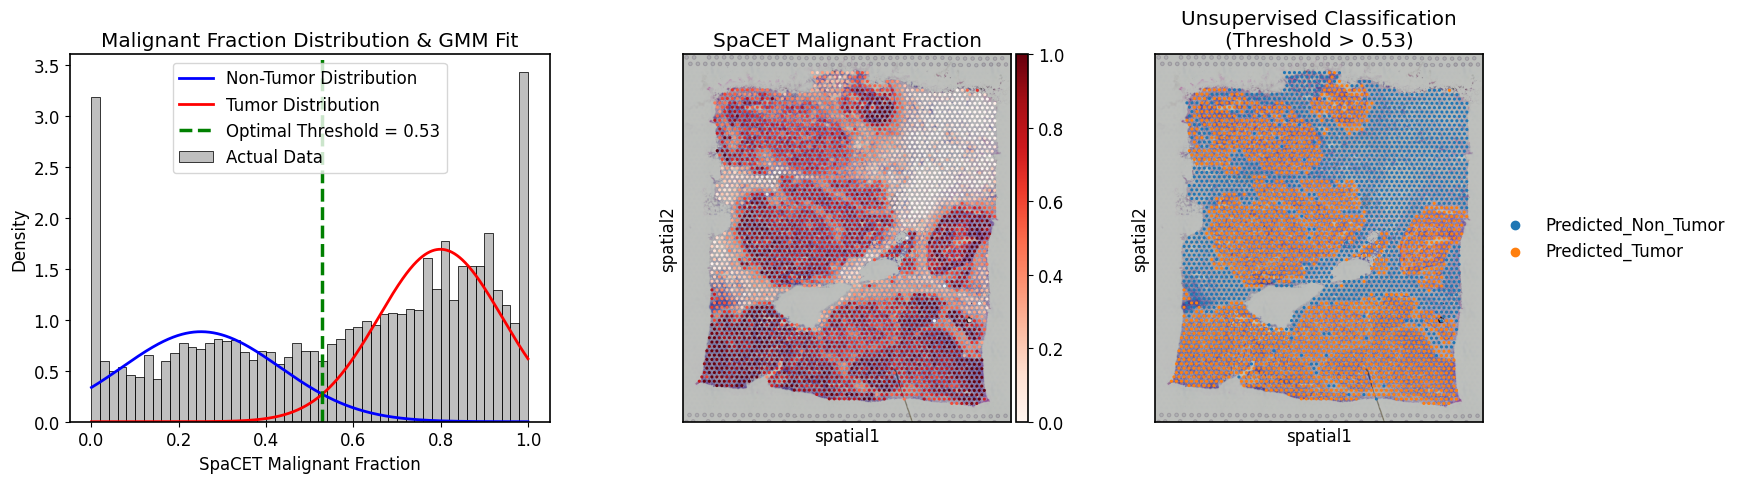

✅ 划分标签已保存至: /home/zhangjunyi/xiangmu/nichecompass-main/outputs/Human_breast_cancer_ViHBC/zhibiao/SpaCET/GMM_Tumor_NonTumor_Pred_Labels.csv
✅ 阈值结果已保存至: /home/zhangjunyi/xiangmu/nichecompass-main/outputs/Human_breast_cancer_ViHBC/zhibiao/SpaCET/GMM_Optimal_Threshold_Result.csv

🎉 全部完成！所有文件已保存至指定文件夹


In [10]:
import anndata as ad
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
import os  # 新增：用于创建文件夹/路径管理

# ==========================================
# 🔥 固定输出路径（你指定的文件夹）
# ==========================================
SAVE_DIR = "/home/zhangjunyi/xiangmu/nichecompass-main/outputs/Human_breast_cancer_ViHBC/zhibiao/SpaCET"
os.makedirs(SAVE_DIR, exist_ok=True)  # 自动创建文件夹，不存在则新建

# ==========================================
# 1. 读取数据
# ==========================================
file_path = "/home/zhangjunyi/xiangmu/nichecompass-main/datasets/Human_breast_cancer/Human_breast_cancer_ViHBC/Human_breast_cancer_integrated_with_SpaCET.h5ad"
print("正在加载数据...")
adata = ad.read_h5ad(file_path)

# ==========================================
# 1. 提取 SpaCET 的 Malignant 分数
# ==========================================
# 过滤掉 NaN 值（如果有背景点）
malignant_scores = adata.obs['Malignant'].dropna().values
# GMM 要求输入是 2D 数组 (n_samples, 1)
X = malignant_scores.reshape(-1, 1)

# ==========================================
# 2. 使用 GMM (高斯混合模型) 自动寻找最优阈值
# ==========================================
print("正在使用高斯混合模型 (GMM) 拟合数据分布...")
# 假设数据分为 2 类（肿瘤 vs 非肿瘤）
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
gmm.fit(X)

# 找出两个分布的均值，区分哪个是非肿瘤(低均值)，哪个是肿瘤(高均值)
means = gmm.means_.flatten()
class_non_tumor_idx = np.argmin(means)
class_tumor_idx = np.argmax(means)

# 寻找两个正态分布交叉的边界点 (即最优阈值)
# 我们在两个均值之间生成 1000 个密集点，看哪一个点模型预测的分类发生了反转
x_test = np.linspace(means[class_non_tumor_idx], means[class_tumor_idx], 1000).reshape(-1, 1)
preds = gmm.predict(x_test)

# 找到分类反转的索引
flip_index = np.where(preds[:-1] != preds[1:])[0]

if len(flip_index) > 0:
    optimal_threshold = x_test[flip_index[0]][0]
else:
    # 极端情况下如果找不到交点，取两个均值的中间值
    optimal_threshold = np.mean(means)

print(f"✨ [无监督] 自动计算出的最优划分阈值为: {optimal_threshold:.4f}")

# ==========================================
# 3. 将新的划分应用到 adata 中
# ==========================================
col_name = f'Unsupervised_Pred_{optimal_threshold:.2f}'
adata.obs[col_name] = np.where(
    adata.obs['Malignant'] > optimal_threshold, 
    'Predicted_Tumor', 
    'Predicted_Non_Tumor'
)
adata.obs[col_name] = adata.obs[col_name].astype('category')

# ==========================================
# 4. 可视化：分布图 (解释为什么选这个阈值) + 空间图
# ==========================================
fig = plt.figure(figsize=(18, 5))

# -----------------
# 子图 1: 分数分布与 GMM 拟合曲线
# -----------------
ax1 = plt.subplot(1, 3, 1)
# 画直方图
sns.histplot(malignant_scores, bins=50, stat='density', alpha=0.5, color='gray', ax=ax1, label='Actual Data')

# 画 GMM 拟合出来的两个正态分布曲线
x_plot = np.linspace(0, 1, 1000).reshape(-1, 1)
logprob = gmm.score_samples(x_plot)
pdf = np.exp(logprob)
responsibilities = gmm.predict_proba(x_plot)

pdf_non_tumor = pdf * responsibilities[:, class_non_tumor_idx]
pdf_tumor = pdf * responsibilities[:, class_tumor_idx]

ax1.plot(x_plot, pdf_non_tumor, color='blue', label='Non-Tumor Distribution', lw=2)
ax1.plot(x_plot, pdf_tumor, color='red', label='Tumor Distribution', lw=2)

# 画阈值垂直线
ax1.axvline(optimal_threshold, color='green', linestyle='--', lw=2.5, 
            label=f'Optimal Threshold = {optimal_threshold:.2f}')

ax1.set_title('Malignant Fraction Distribution & GMM Fit')
ax1.set_xlabel('SpaCET Malignant Fraction')
ax1.set_ylabel('Density')
ax1.legend()

# -----------------
# 子图 2: SpaCET 连续分数的空间分布
# -----------------
ax2 = plt.subplot(1, 3, 2)
sc.pl.spatial(adata, color='Malignant', title='SpaCET Malignant Fraction', 
              spot_size=170, cmap='Reds', ax=ax2, show=False)

# -----------------
# 子图 3: 使用自动阈值划分后的离散空间分布
# -----------------
ax3 = plt.subplot(1, 3, 3)
sc.pl.spatial(adata, color=col_name, title=f'Unsupervised Classification\n(Threshold > {optimal_threshold:.2f})', 
              spot_size=170, ax=ax3, show=False)

plt.tight_layout()

# ==========================================
# 🔥 新增1：保存图片到指定路径（高清300dpi）
# ==========================================
img_save_path = os.path.join(SAVE_DIR, "GMM_Malignant_Threshold_Plot.png")
plt.savefig(img_save_path, dpi=300, bbox_inches='tight')
print(f"\n✅ 图片已保存至: {img_save_path}")

plt.show()

# ==========================================
# 🔥 新增2：保存肿瘤/非肿瘤划分标签为CSV
# ==========================================
label_save_path = os.path.join(SAVE_DIR, "GMM_Tumor_NonTumor_Pred_Labels.csv")
# 保存Spot ID + 划分标签 + 原始Malignant分数
label_df = adata.obs[[col_name, 'Malignant']].copy()
label_df.index.name = "Spot_ID"
label_df.to_csv(label_save_path, encoding='utf-8-sig')
print(f"✅ 划分标签已保存至: {label_save_path}")

# ==========================================
# 🔥 新增3：保存最优阈值结果为CSV
# ==========================================
threshold_save_path = os.path.join(SAVE_DIR, "GMM_Optimal_Threshold_Result.csv")
threshold_df = pd.DataFrame({
    "Metric": ["Optimal_GMM_Threshold"],
    "Value": [round(optimal_threshold, 4)]
})
threshold_df.to_csv(threshold_save_path, index=False, encoding='utf-8-sig')
print(f"✅ 阈值结果已保存至: {threshold_save_path}")

print("\n🎉 全部完成！所有文件已保存至指定文件夹")

利用当前阈值计算ARI


===== 正在绘制空间分布对比图 =====


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

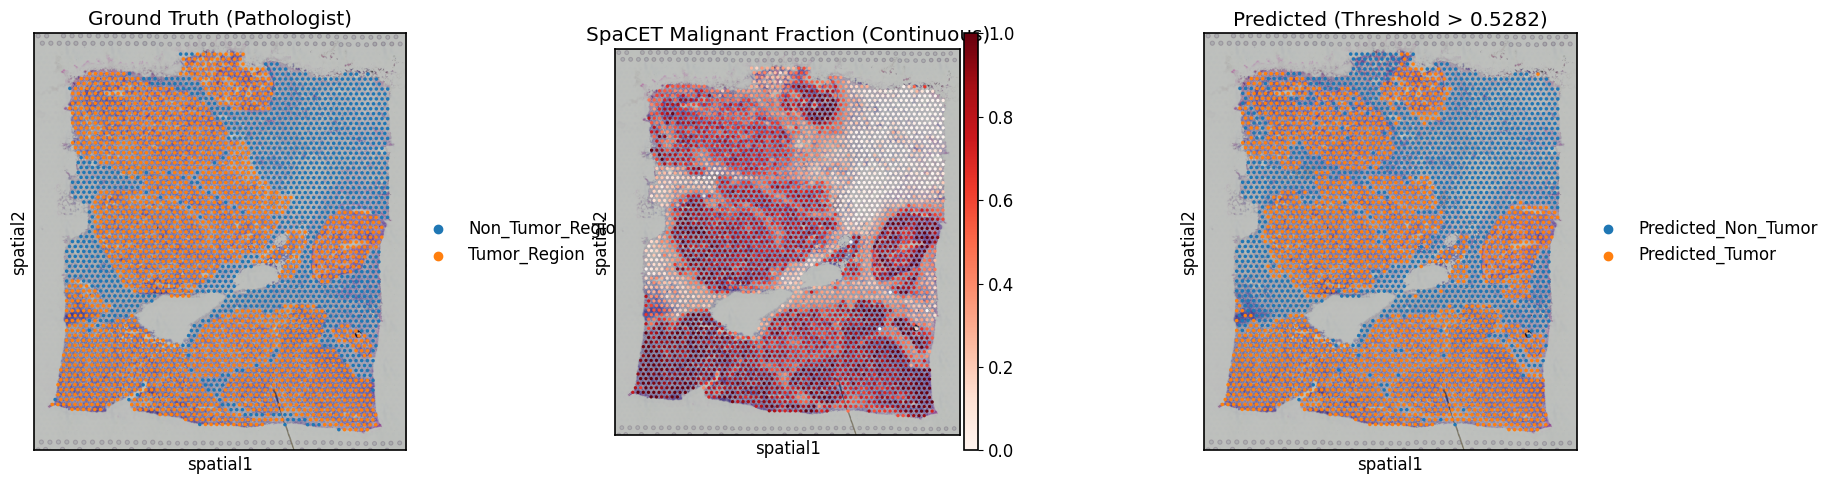


===== 评估指标 =====
使用的切割阈值: Malignant > 0.5282
有效参与计算的 Spot 数量: 3798
✅ 修正后的宏观肿瘤分割 ARI = 0.5106
💡 [探索] 对于该数据集，使 ARI 最高的阈值其实是 0.45 (此时最高 ARI = 0.5225)


In [8]:
import anndata as ad
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score

# ==========================================
# 1. 准备数据与真实标签映射 (Ground Truth)
# ==========================================
# 映射字典：Tumor/Invasive为1(肿瘤)，Healthy/Surrounding为0(非肿瘤)
gt_map_int = {
    'Tumor': 1,
    'Invasive': 1,
    'Surrounding tumor': 0,
    'Healthy': 0
}

# 为了可视化好看，我们新建一个字符串分类列
gt_map_str = {
    'Tumor': 'Tumor_Region',
    'Invasive': 'Tumor_Region',
    'Surrounding tumor': 'Non_Tumor_Region',
    'Healthy': 'Non_Tumor_Region'
}

adata.obs['Ground_Truth_Binary'] = adata.obs['annot_type'].map(gt_map_str).astype('category')
gt_labels_for_math = adata.obs['annot_type'].map(gt_map_int).values

# ==========================================
# 2. 生成预测标签 (基于 0.4 阈值)
# ==========================================
threshold = 0.5282

# 生成预测的字符串标签（用于画图）
adata.obs[f'Pred_Threshold_{threshold}'] = np.where(
    adata.obs['Malignant'] > threshold, 
    'Predicted_Tumor', 
    'Predicted_Non_Tumor'
)
adata.obs[f'Pred_Threshold_{threshold}'] = adata.obs[f'Pred_Threshold_{threshold}'].astype('category')

# 生成预测的整数标签（用于计算 ARI）
pred_labels_for_math = (adata.obs['Malignant'] > threshold).astype(int).values

# ==========================================
# 3. 空间可视化 (核对 0.25 切得合不合理)
# ==========================================
print("\n===== 正在绘制空间分布对比图 =====")
try:
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    
    # 图1：病理学家的金标准（二分类）
    sc.pl.spatial(adata, color='Ground_Truth_Binary', title='Ground Truth (Pathologist)', spot_size=170, ax=axs[0], show=False)
    
    # 图2：SpaCET 推断的恶性细胞连续比例 (热力图)
    sc.pl.spatial(adata, color='Malignant', title='SpaCET Malignant Fraction (Continuous)', spot_size=170, cmap='Reds', ax=axs[1], show=False)
    
    # 图3：0.25 阈值切割后的预测结果
    sc.pl.spatial(adata, color=f'Pred_Threshold_{threshold}', title=f'Predicted (Threshold > {threshold})', spot_size=170, ax=axs[2], show=False)
    
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"可视化失败: {e}")

# ==========================================
# 4. 计算 ARI 指标
# ==========================================
# 过滤掉注释为 NaN 的点（如组织切片外围的背景点）
valid_mask = ~np.isnan(gt_labels_for_math)
gt_valid = gt_labels_for_math[valid_mask]
pred_valid = pred_labels_for_math[valid_mask]

# 计算 ARI
ari = adjusted_rand_score(gt_valid, pred_valid)

print("\n===== 评估指标 =====")
print(f"使用的切割阈值: Malignant > {threshold}")
print(f"有效参与计算的 Spot 数量: {len(gt_valid)}")
print(f"✅ 修正后的宏观肿瘤分割 ARI = {ari:.4f}")

# ==========================================
# [进阶选项]：寻找使 ARI 最大的最优阈值
# ==========================================
# 如果你想知道到底切多少能让 ARI 最高，可以跑下面这段
best_ari = -1
best_t = 0
for t in np.arange(0.1, 0.9, 0.05):
    temp_pred = (adata.obs['Malignant'] > t).astype(int).values[valid_mask]
    temp_ari = adjusted_rand_score(gt_valid, temp_pred)
    if temp_ari > best_ari:
        best_ari = temp_ari
        best_t = t
print(f"💡 [探索] 对于该数据集，使 ARI 最高的阈值其实是 {best_t:.2f} (此时最高 ARI = {best_ari:.4f})")